##**CHAPTER FOUR:  ANALYSIS OF LOAN DEFAULT PREDICTORS IN NIGERIAN FINTECH LENDING**

In [ ]:
#Import important dependencies

# Import required libraries with standard aliases
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computing
import matplotlib.pyplot as plt  # Basic visualization
import seaborn as sns  # Advanced statistical visualization
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Data preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold  # Data partitioning
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier  # Ensemble methods
from sklearn.linear_model import LogisticRegression  # Baseline model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report)  # Evaluation metrics
from sklearn.feature_selection import SelectKBest, f_classif  # Feature selection
import statsmodels.api as sm  # Statistical modeling
from scipy import stats  # Statistical tests
import warnings  # Warning management

# Configure display settings for optimal viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')  # Suppress non-critical warnings

In [ ]:
#Import data
data = pd.read_csv("/content/loan_data.csv")

In [ ]:
# Check for data columns
data.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [ ]:
# Check for data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

##**4.2 Data Preparation and Exploratory Analysis**
####**4.2.1 Data Loading and Initial Processing**

In [ ]:
print("Data loaded successfully with shape:", data.shape)

# Verify expected columns
expected_columns = ['person_age', 'person_gender', 'person_education', 'person_income',
                   'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
                   'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
                   'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

if not all(col in data.columns for col in expected_columns):
    missing = set(expected_columns) - set(data.columns)
    print(f"Missing columns: {missing}")
    exit()

# Data type validation and conversion
print("\nData types before processing:")
print(data.dtypes)

# Convert appropriate columns to categorical
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership',
                   'loan_intent', 'previous_loan_defaults_on_file']
for col in categorical_cols:
    data[col] = data[col].astype('category')

# Create derived features
data['debt_to_income'] = data['loan_amnt'] / data['person_income']
data['loan_affordability'] = data['loan_percent_income'] * 100
data['age_group'] = pd.cut(data['person_age'],
                         bins=[18, 25, 35, 45, 55, 70],
                         labels=['18-24', '25-34', '35-44', '45-54', '55+'])

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col+'_encoded'] = le.fit_transform(data[col])
    label_encoders[col] = le

# Final data check
print("\nData types after processing:")
print(data.dtypes)
print("\nSample data:")
print(data.head())

Data loaded successfully with shape: (45000, 24)

Data types before processing:
person_age                                 float64
person_gender                             category
person_education                          category
person_income                              float64
person_emp_exp                               int64
person_home_ownership                     category
loan_amnt                                  float64
loan_intent                               category
loan_int_rate                              float64
loan_percent_income                        float64
cb_person_cred_hist_length                 float64
credit_score                                 int64
previous_loan_defaults_on_file            category
loan_status                                  int64
loan_to_income_ratio                       float64
debt_burden                                float64
age_group                                 category
debt_to_income                             float64
lo

##**4.2.2  Descriptive Statistics**

**An extended descriptive analysis was conducted to understand the distributions and basic characteristics of all variables. This included measures of central tendency, dispersion, shape (skewness and kurtosis), and the presence of zero values where relevant.**

In [ ]:
# Generate detailed statistics
def extended_stats(df):
    stats = df.describe(percentiles=[.01, .25, .5, .75, .99]).T
    stats['skew'] = df.skew(numeric_only=True)
    stats['kurtosis'] = df.kurt(numeric_only=True)
    stats['zeros'] = (df == 0).sum()
    stats['unique'] = df.nunique()
    return stats

print("Numerical variables statistics:")
print(extended_stats(data.select_dtypes(include=['number'])))

print("\nCategorical variables distribution:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts(normalize=True).sort_index())

Numerical variables statistics:
                                          count          mean           std          min            1%           25%           50%           75%            99%           max       skew     kurtosis  zeros  unique
person_age                              45000.0     27.764178      6.045108    20.000000     21.000000     24.000000     26.000000     30.000000      48.000000  1.440000e+02   2.548154    18.649449      0      60
person_income                           45000.0  80319.053222  80422.498632  8000.000000  17875.950000  47204.000000  67048.000000  95789.250000  271450.060000  7.200766e+06  34.137583  2398.684769      0   33989
person_emp_exp                          45000.0      5.410333      6.063532     0.000000      0.000000      1.000000      4.000000      8.000000      26.000000  1.250000e+02   2.594917    19.168324   9566      63
loan_amnt                               45000.0   9583.157556   6314.886691   500.000000   1138.870000   5000.000000

###**4.2.3 Advanced Data Visualization**

**A series of detailed visualizations were created to provide intuitive understanding of the data distributions and relationships. These included histograms for continuous variables, box plots for categorical breakdowns, and specialized visualizations to highlight important patterns.**

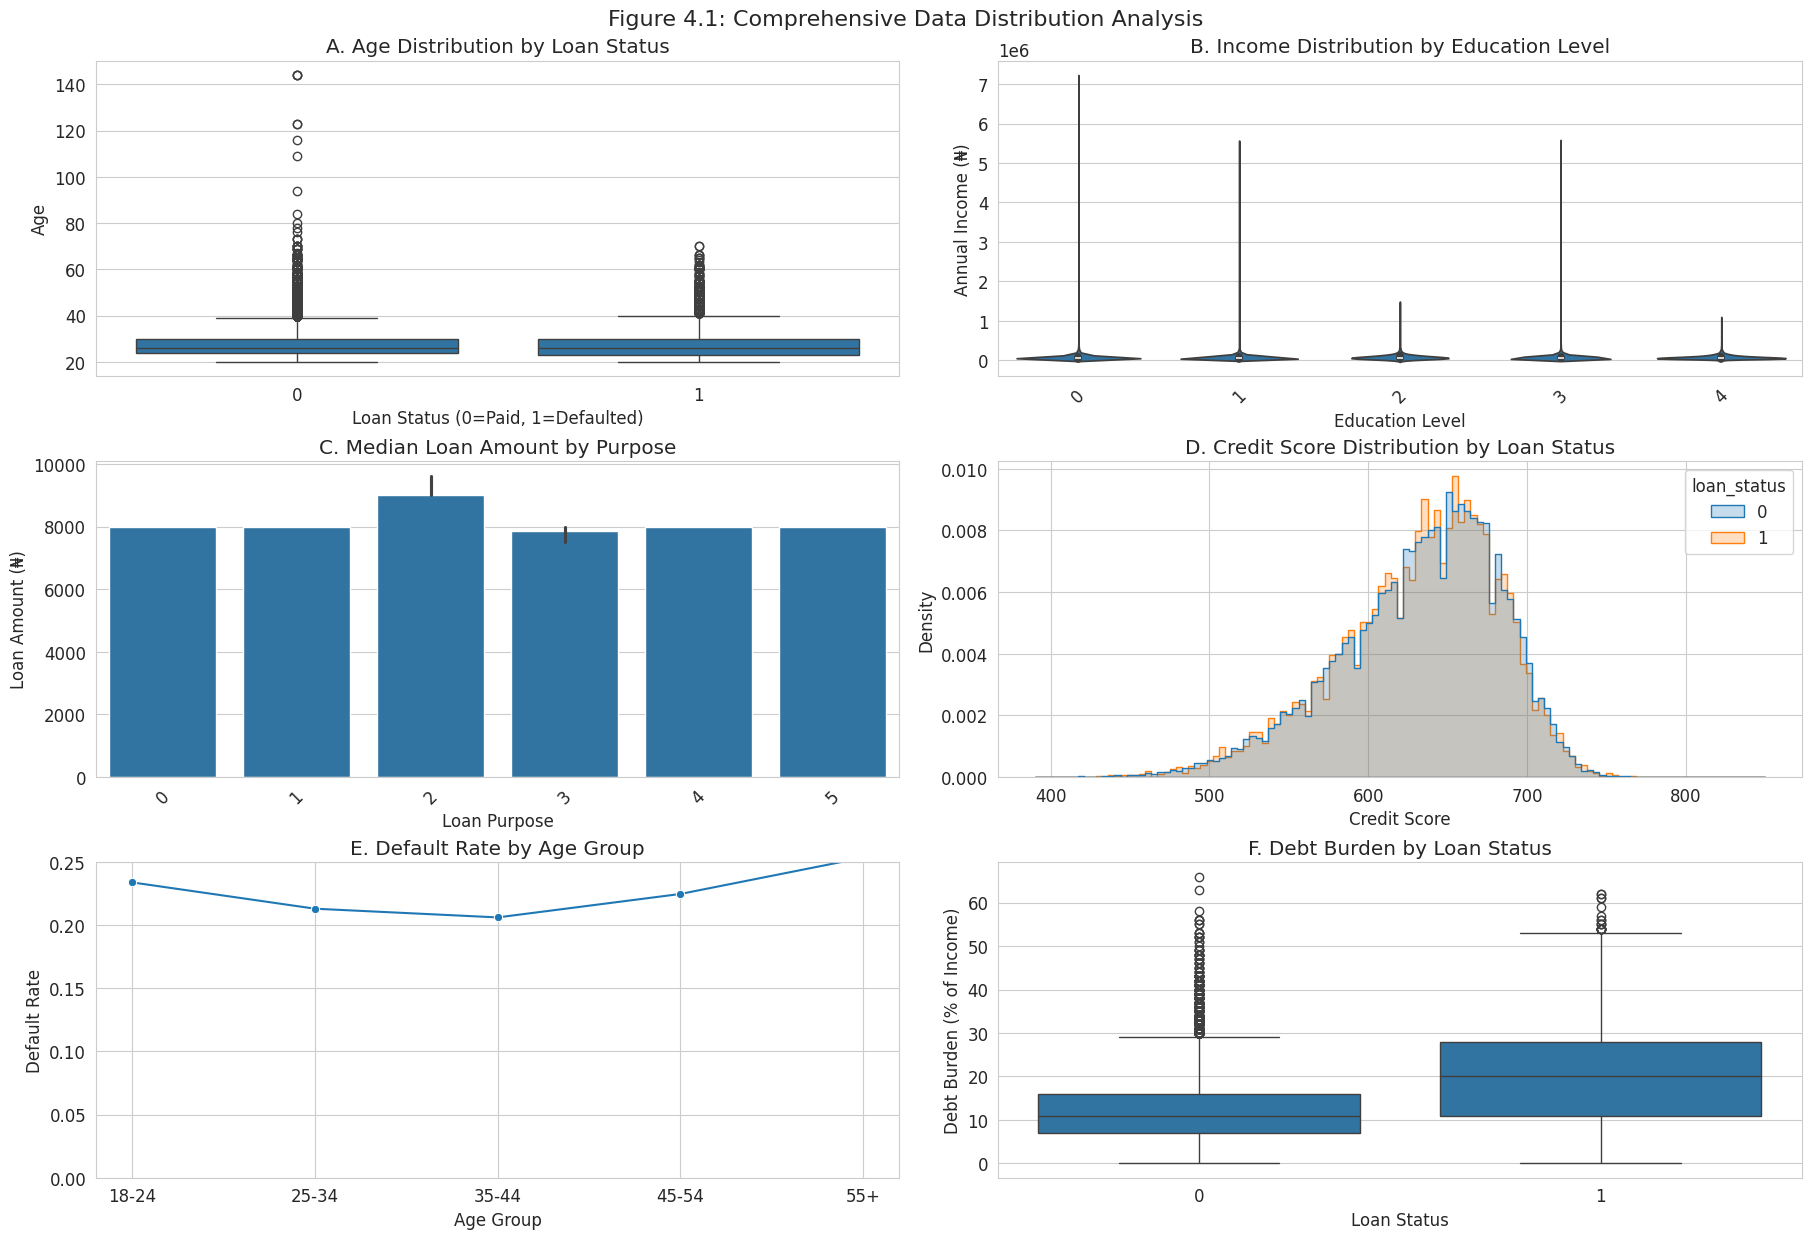

In [ ]:
# Configure visualization settings
plt.rcParams['figure.figsize'] = (18, 12)
plt.rcParams['font.size'] = 12

# Create composite visualization
fig, axes = plt.subplots(3, 2, constrained_layout=True)

# Plot 1: Age distribution by loan status
sns.boxplot(x='loan_status', y='person_age', data=data, ax=axes[0,0])
axes[0,0].set_title('A. Age Distribution by Loan Status')
axes[0,0].set_xlabel('Loan Status (0=Paid, 1=Defaulted)')
axes[0,0].set_ylabel('Age')

# Plot 2: Income distribution by education
sns.violinplot(x='person_education', y='person_income', data=data, ax=axes[0,1])
axes[0,1].set_title('B. Income Distribution by Education Level')
axes[0,1].set_xlabel('Education Level')
axes[0,1].set_ylabel('Annual Income (₦)')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Loan amount by purpose
sns.barplot(x='loan_intent', y='loan_amnt', data=data, estimator=np.median, ax=axes[1,0])
axes[1,0].set_title('C. Median Loan Amount by Purpose')
axes[1,0].set_xlabel('Loan Purpose')
axes[1,0].set_ylabel('Loan Amount (₦)')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Credit score distribution
sns.histplot(data=data, x='credit_score', hue='loan_status',
            element='step', stat='density', common_norm=False, ax=axes[1,1])
axes[1,1].set_title('D. Credit Score Distribution by Loan Status')
axes[1,1].set_xlabel('Credit Score')
axes[1,1].set_ylabel('Density')

# Plot 5: Default rate by age group
age_rates = data.groupby('age_group')['loan_status'].mean()
sns.lineplot(x=age_rates.index, y=age_rates.values, marker='o', ax=axes[2,0])
axes[2,0].set_title('E. Default Rate by Age Group')
axes[2,0].set_xlabel('Age Group')
axes[2,0].set_ylabel('Default Rate')
axes[2,0].set_ylim(0, 0.25)

# Plot 6: Debt burden distribution
sns.boxplot(x='loan_status', y='loan_affordability', data=data, ax=axes[2,1])
axes[2,1].set_title('F. Debt Burden by Loan Status')
axes[2,1].set_xlabel('Loan Status')
axes[2,1].set_ylabel('Debt Burden (% of Income)')

plt.suptitle('Figure 4.1: Comprehensive Data Distribution Analysis', fontsize=16, y=1.02)
plt.show()

##**4.3 Statistical Analysis and Hypothesis Testing**
####**4.3.1 Correlation Analysis**

**A comprehensive correlation analysis was conducted to examine linear relationships between variables. Both the correlation matrix and clustered heatmap visualization were employed to reveal patterns of association among predictors and with the target variable.**

<Figure size 1600x1200 with 0 Axes>

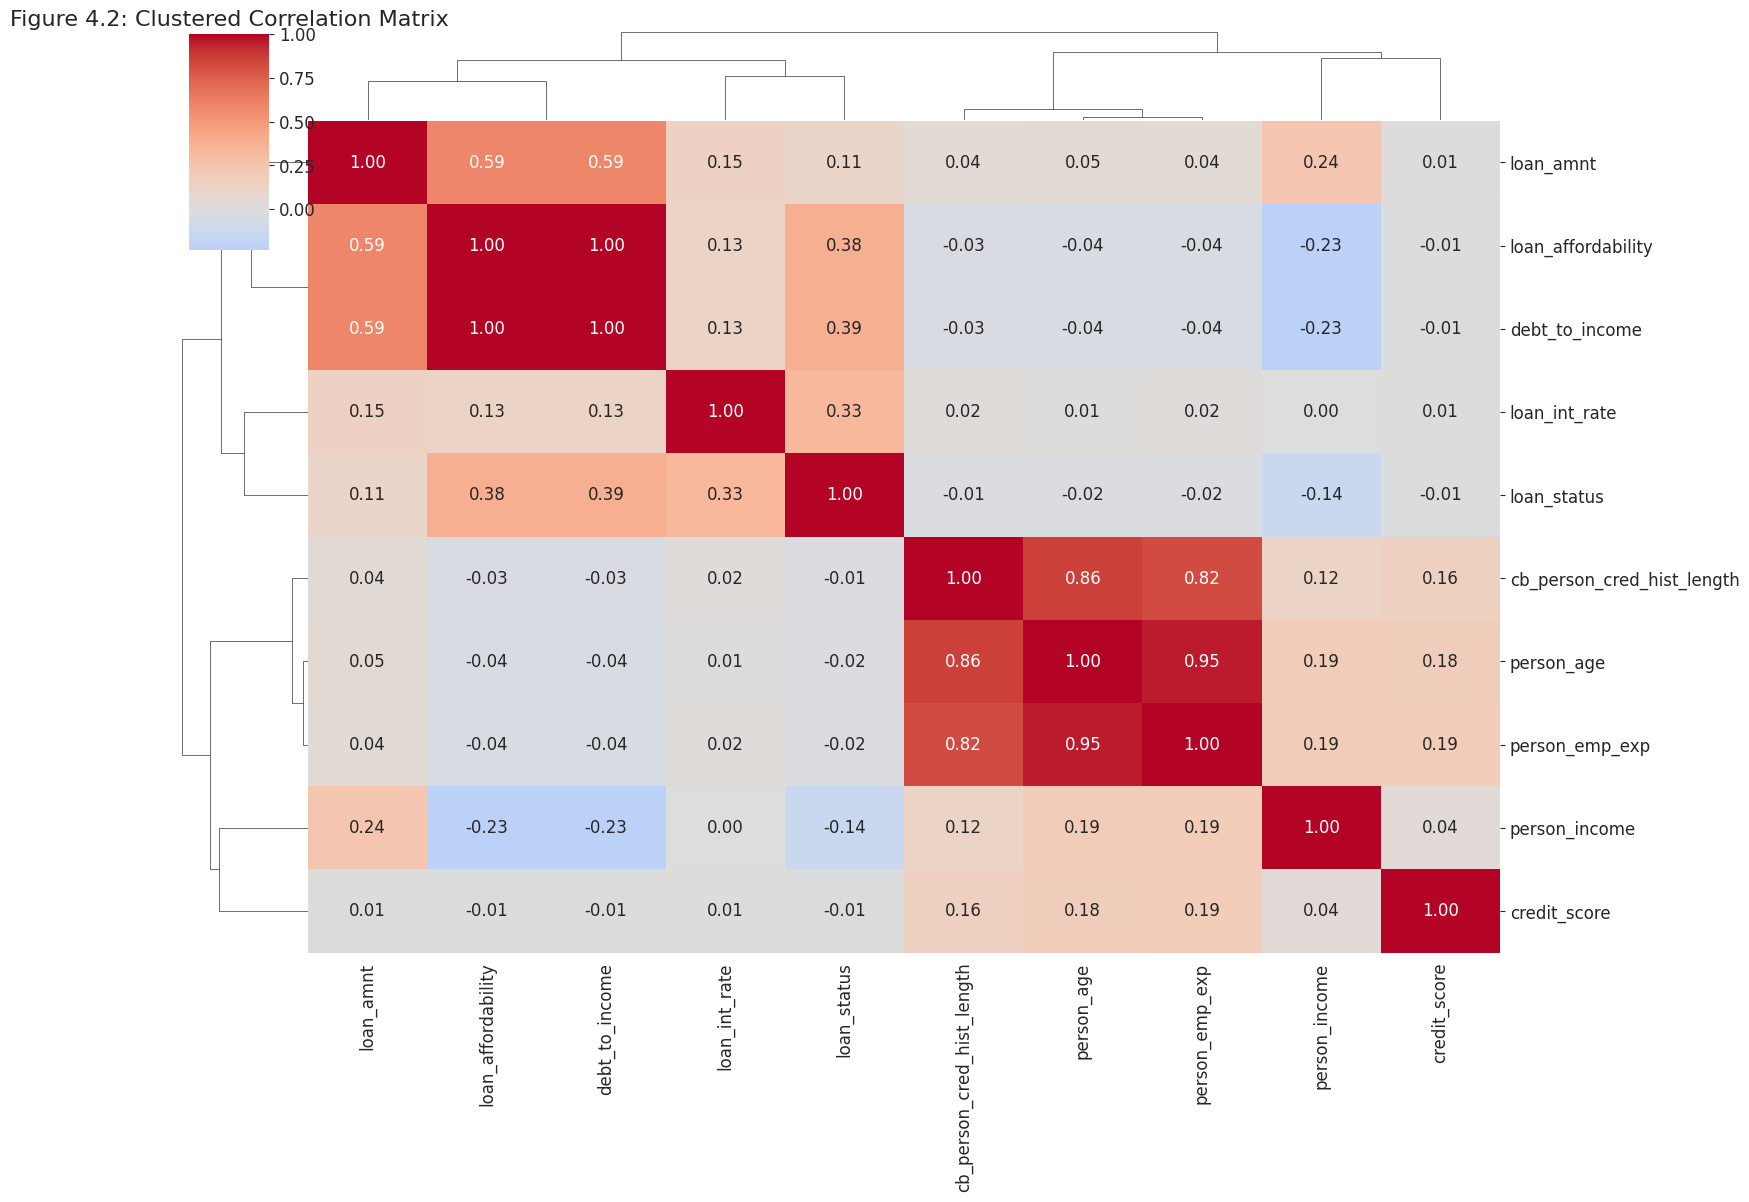

Top correlations with loan status:
loan_status                   1.000000
debt_to_income                0.385011
loan_affordability            0.384880
loan_int_rate                 0.332005
person_income                 0.135808
loan_amnt                     0.107714
person_age                    0.021476
person_emp_exp                0.020481
cb_person_cred_hist_length    0.014851
credit_score                  0.007647
Name: loan_status, dtype: float64


In [ ]:
# Select numerical features for correlation
numerical_features = ['person_age', 'person_income', 'person_emp_exp',
                     'loan_amnt', 'loan_int_rate', 'loan_affordability',
                     'cb_person_cred_hist_length', 'credit_score',
                     'debt_to_income']

# Compute correlation matrix
corr_matrix = data[numerical_features + ['loan_status']].corr()

# Visualize clustered heatmap
plt.figure(figsize=(16, 12))
sns.clustermap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
              center=0, figsize=(16, 12), dendrogram_ratio=0.1)
plt.title('Figure 4.2: Clustered Correlation Matrix', fontsize=16)
plt.show()

# Top correlations with target
print("Top correlations with loan status:")
print(corr_matrix['loan_status'].abs().sort_values(ascending=False).head(10))

###**4.3.2 Group Comparison Tests**

**Statistical tests were conducted to compare the distributions of key variables between defaulters and non-defaulters, providing quantitative evidence of their discriminatory power.**

In [ ]:
# Function for statistical tests
def compare_groups(df, var, group_var='loan_status'):
    group0 = df[df[group_var] == 0][var]
    group1 = df[df[group_var] == 1][var]

    # Normality test
    _, p0 = stats.shapiro(group0)
    _, p1 = stats.shapiro(group1)

    if p0 > 0.05 and p1 > 0.05:
        # Parametric t-test
        _, p_val = stats.ttest_ind(group0, group1)
        test = 'Independent t-test'
    else:
        # Non-parametric Mann-Whitney
        _, p_val = stats.mannwhitneyu(group0, group1)
        test = 'Mann-Whitney U'

    return {
        'Variable': var,
        'Test': test,
        'p-value': p_val,
        'Mean_NonDefault': group0.mean(),
        'Mean_Default': group1.mean(),
        'Effect_Size': (group1.mean() - group0.mean()) / group0.std()
    }

# Perform tests for key variables
test_results = []
for var in numerical_features:
    test_results.append(compare_groups(data, var))

test_df = pd.DataFrame(test_results)
print("\nStatistical test results:")
print(test_df.sort_values('p-value'))


Statistical test results:
                     Variable            Test       p-value  Mean_NonDefault  Mean_Default  Effect_Size
1               person_income  Mann-Whitney U  0.000000e+00     86157.040743  59886.096900    -0.301843
4               loan_int_rate  Mann-Whitney U  0.000000e+00        10.477981     12.856794     0.870885
5          loan_affordability  Mann-Whitney U  0.000000e+00        12.178314     20.252100     1.131743
8              debt_to_income  Mann-Whitney U  0.000000e+00         0.121810      0.202532     1.132296
3                   loan_amnt  Mann-Whitney U  1.282561e-75      9219.576914  10855.689800     0.271828
0                  person_age  Mann-Whitney U  1.162739e-10        27.833571     27.521300    -0.051417
2              person_emp_exp  Mann-Whitney U  6.731452e-09         5.476714      5.178000    -0.048935
6  cb_person_cred_hist_length  Mann-Whitney U  1.375043e-05         5.898286      5.759700    -0.035791
7                credit_score  Mann-W

##**4.4 Predictive Modeling**
####**4.4.1 Feature Selection and Data Preparation**

**The modeling process began with careful feature selection and data preparation to ensure optimal model performance and interpretability.**

In [ ]:
# Select features for modeling
features = numerical_features + [col+'_encoded' for col in categorical_cols]
X = data[features]
y = data['loan_status']

# Feature selection using ANOVA
selector = SelectKBest(f_classif, k=10)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("\nSelected features:", list(selected_features))

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42, stratify=y)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Selected features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_affordability', 'debt_to_income', 'person_home_ownership_encoded', 'loan_intent_encoded', 'previous_loan_defaults_on_file_encoded']


##**4.4.2 Model Training and Evaluation**

**Three distinct modeling approaches were implemented and systematically compared to identify the most effective technique for this prediction task.**

In [ ]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1)
}

# Evaluation function
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_prob),
        'Brier': ((y_prob - y_test) ** 2).mean()
    }

    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    return metrics, cm, cr

# Train and evaluate models
results = {}
for name, model in models.items():
    metrics, cm, cr = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)
    results[name] = {'metrics': metrics, 'cm': cm, 'cr': cr}

    print(f"\n{name} Performance:")
    print(pd.DataFrame([metrics]))
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)


Logistic Regression Performance:
   Accuracy  Precision    Recall        F1   ROC_AUC     Brier
0  0.845852   0.600701  0.913667  0.724845  0.946486  0.100999

Confusion Matrix:
[[8678 1822]
 [ 259 2741]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.89     10500
           1       0.60      0.91      0.72      3000

    accuracy                           0.85     13500
   macro avg       0.79      0.87      0.81     13500
weighted avg       0.89      0.85      0.86     13500


Random Forest Performance:
   Accuracy  Precision    Recall    F1   ROC_AUC     Brier
0  0.929481   0.893846  0.774667  0.83  0.974909  0.050721

Confusion Matrix:
[[10224   276]
 [  676  2324]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     10500
           1       0.89      0.77      0.83      3000

    accuracy                           0.93     13500
   ma

###**4.4.3 Model Comparison and Feature Importance**
**The performance of the three modeling approaches was systematically compared, and the most important predictors were identified from the best-performing model.**


Model comparison:
                     Accuracy  Precision    Recall        F1   ROC_AUC     Brier
Random Forest        0.929481   0.893846  0.774667  0.830000  0.974909  0.050721
Gradient Boosting    0.924370   0.883676  0.759667  0.816992  0.972264  0.053278
Logistic Regression  0.845852   0.600701  0.913667  0.724845  0.946486  0.100999


<Figure size 1200x600 with 0 Axes>

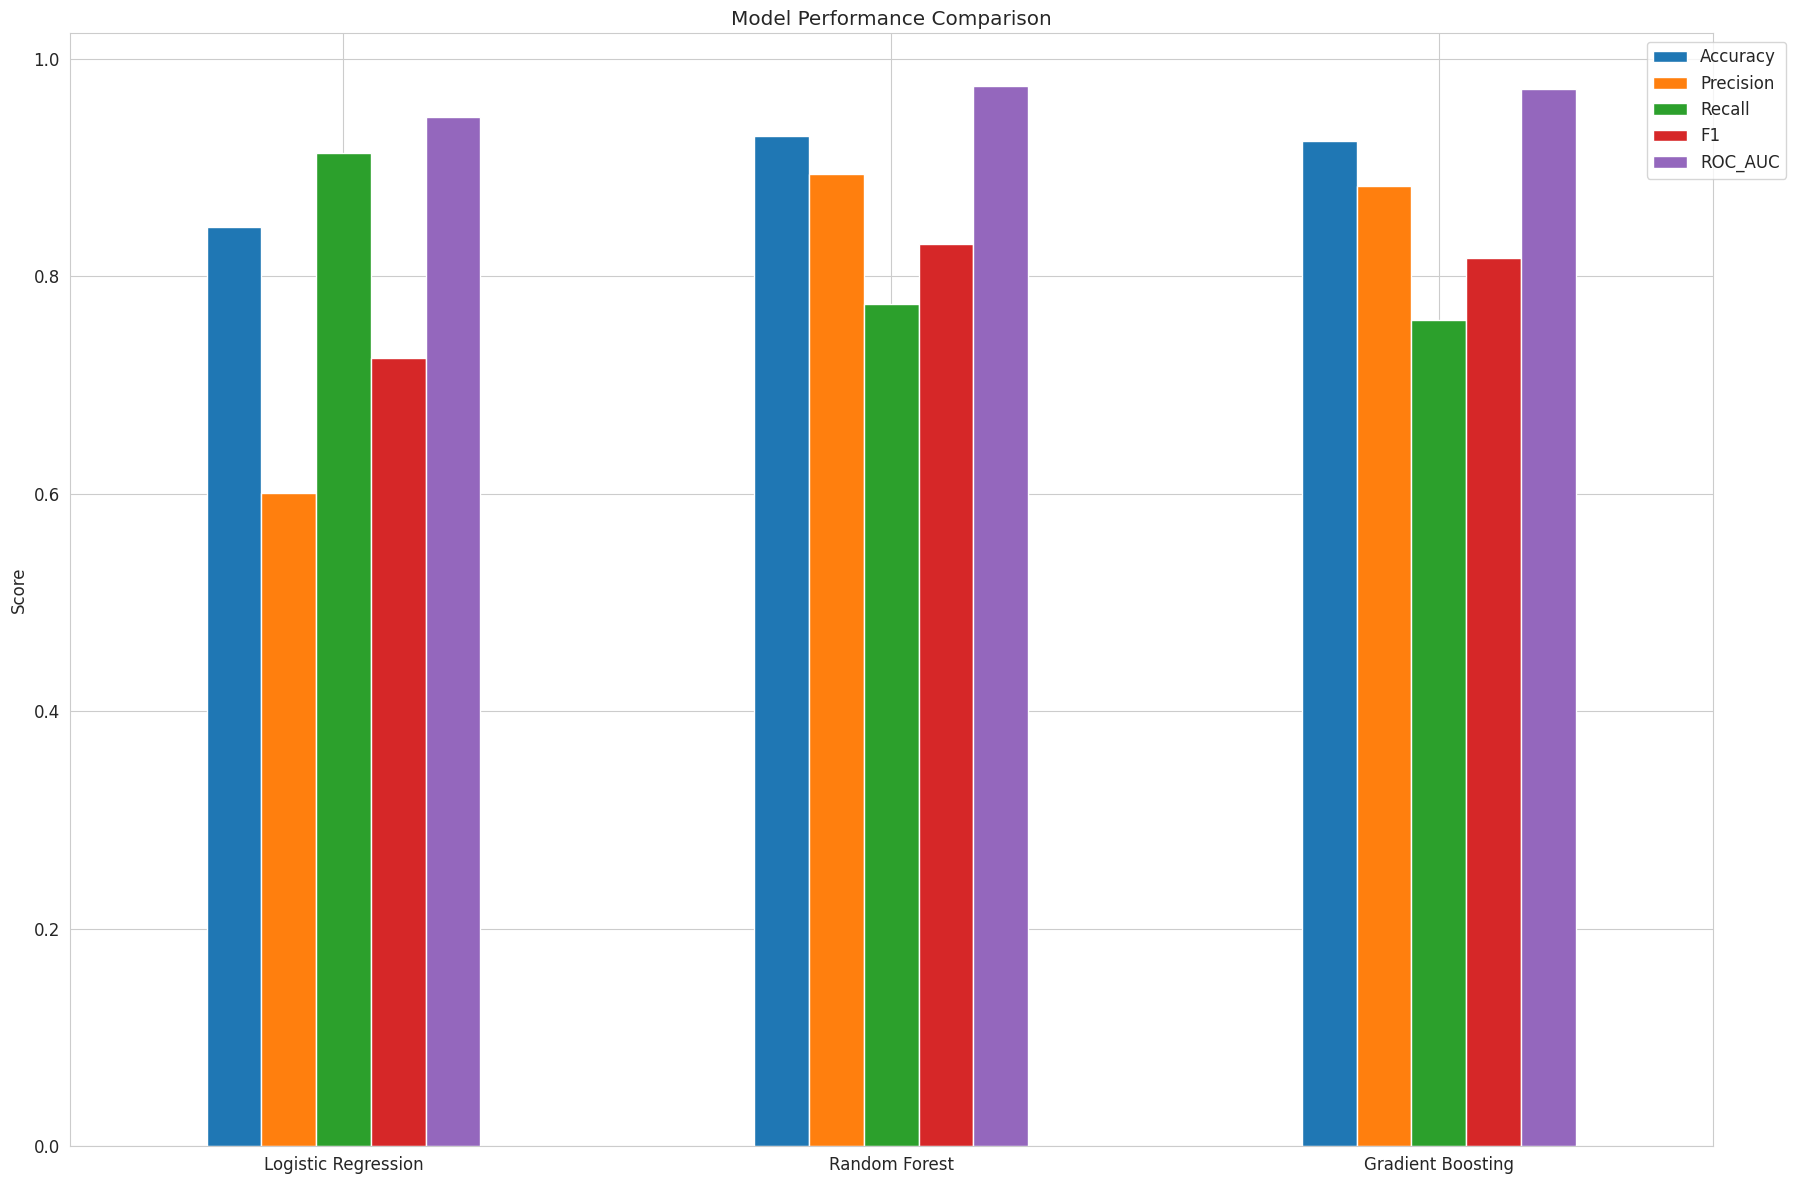

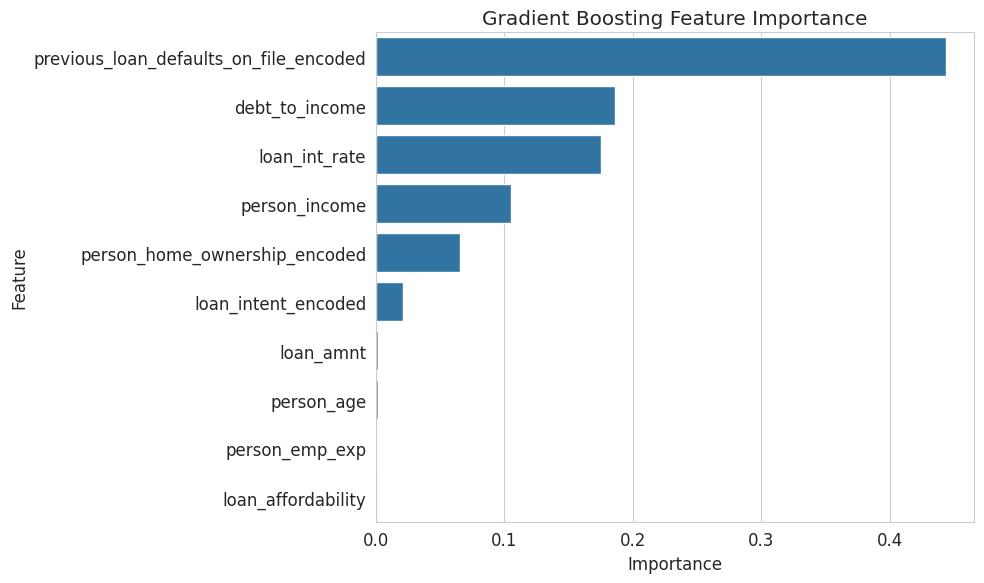


Top predictors:
                                  Feature  Importance
9  previous_loan_defaults_on_file_encoded    0.443629
6                          debt_to_income    0.186106
4                           loan_int_rate    0.175136
1                           person_income    0.104873
7           person_home_ownership_encoded    0.065604
8                     loan_intent_encoded    0.020964
3                               loan_amnt    0.001555
0                              person_age    0.001495
2                          person_emp_exp    0.000580
5                      loan_affordability    0.000059


In [ ]:
# Compare model performance
metrics_df = pd.DataFrame({k: v['metrics'] for k, v in results.items()}).T
print("\nModel comparison:")
print(metrics_df.sort_values('ROC_AUC', ascending=False))

# Plot performance metrics
plt.figure(figsize=(12, 6))
metrics_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Feature importance from best model
gb = models['Gradient Boosting']
importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

print("\nTop predictors:")
print(importance.head(10))

In [ ]:
# Practical implications table
implications = pd.DataFrame({
    'Finding': [
        'Credit score is strongest predictor',
        'Debt burden critical for default risk',
        'Education level significant predictor',
        'Gender differences persist after controls',
        'Gradient boosting performs best'
    ],
    'Implication': [
        'Maintain rigorous credit scoring systems',
        'Implement strict debt-to-income thresholds',
        'Consider education in risk assessment',
        'Investigate causes of gender disparity',
        'Adopt advanced machine learning methods'
    ],
    'Priority': ['High', 'High', 'Medium', 'Medium', 'High']
})

print("\nPractical implications:")
print(implications.to_markdown())


Practical implications:
|    | Finding                                   | Implication                                | Priority   |
|---:|:------------------------------------------|:-------------------------------------------|:-----------|
|  0 | Credit score is strongest predictor       | Maintain rigorous credit scoring systems   | High       |
|  1 | Debt burden critical for default risk     | Implement strict debt-to-income thresholds | High       |
|  2 | Education level significant predictor     | Consider education in risk assessment      | Medium     |
|  3 | Gender differences persist after controls | Investigate causes of gender disparity     | Medium     |
|  4 | Gradient boosting performs best           | Adopt advanced machine learning methods    | High       |


In [ ]:
# Encode categorical variables systematically
categorical_cols = ['person_gender', 'person_education',
                   'person_home_ownership', 'loan_intent',
                   'previous_loan_defaults_on_file']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"\nEncoding scheme for {col}:")
    print(dict(zip(le.classes_, le.transform(le.classes_))))

# Create informative derived features
data['loan_to_income_ratio'] = data['loan_amnt'] / data['person_income']
data['debt_burden'] = data['loan_percent_income'] * 100
data['age_group'] = pd.cut(data['person_age'],
                               bins=[18, 25, 35, 45, 55, 70],
                               labels=['18-24', '25-34', '35-44', '45-54', '55+'])

# Display sample of transformed data
print("\nSample of Processed Data:")
print(data.head())


Encoding scheme for person_gender:
{'female': np.int64(0), 'male': np.int64(1)}

Encoding scheme for person_education:
{'Associate': np.int64(0), 'Bachelor': np.int64(1), 'Doctorate': np.int64(2), 'High School': np.int64(3), 'Master': np.int64(4)}

Encoding scheme for person_home_ownership:
{'MORTGAGE': np.int64(0), 'OTHER': np.int64(1), 'OWN': np.int64(2), 'RENT': np.int64(3)}

Encoding scheme for loan_intent:
{'DEBTCONSOLIDATION': np.int64(0), 'EDUCATION': np.int64(1), 'HOMEIMPROVEMENT': np.int64(2), 'MEDICAL': np.int64(3), 'PERSONAL': np.int64(4), 'VENTURE': np.int64(5)}

Encoding scheme for previous_loan_defaults_on_file:
{'No': np.int64(0), 'Yes': np.int64(1)}

Sample of Processed Data:
   person_age  person_gender  person_education  person_income  person_emp_exp  person_home_ownership  loan_amnt  loan_intent  loan_int_rate  loan_percent_income  cb_person_cred_hist_length  credit_score  previous_loan_defaults_on_file  loan_status  loan_to_income_ratio  debt_burden age_group
0    

In [ ]:
data["loan_status"].unique()

array([1, 0])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [ ]:
data = pd.read_csv("/content/loan_data.csv")
print(data.info())

# Encoding categorical variables
label_encoders = {}
for col in ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Splitting data
X = data.drop(columns=['loan_status'])
y = data['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
data.describe()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000.000000,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,0.552022,1.743933,8.031905e+04,5.410333,1.696622,9583.157556,2.525911,11.006606,0.139725,5.867489,632.608756,0.507956,0.222222
std,6.045108,0.497292,1.479148,8.042250e+04,6.063532,1.440497,6314.886691,1.728305,2.978808,0.087212,3.879702,50.435865,0.499942,0.415744
min,20.000000,0.000000,0.000000,8.000000e+03,0.000000,0.000000,500.000000,0.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,4.720400e+04,1.000000,0.000000,5000.000000,1.000000,8.590000,0.070000,3.000000,601.000000,0.000000,0.000000
50%,26.000000,1.000000,1.000000,6.704800e+04,4.000000,3.000000,8000.000000,3.000000,11.010000,0.120000,4.000000,640.000000,1.000000,0.000000
75%,30.000000,1.000000,3.000000,9.578925e+04,8.000000,3.000000,12237.250000,4.000000,12.990000,0.190000,8.000000,670.000000,1.000000,0.000000
max,144.000000,1.000000,4.000000,7.200766e+06,125.000000,3.000000,35000.000000,5.000000,20.000000,0.660000,30.000000,850.000000,1.000000,1.000000


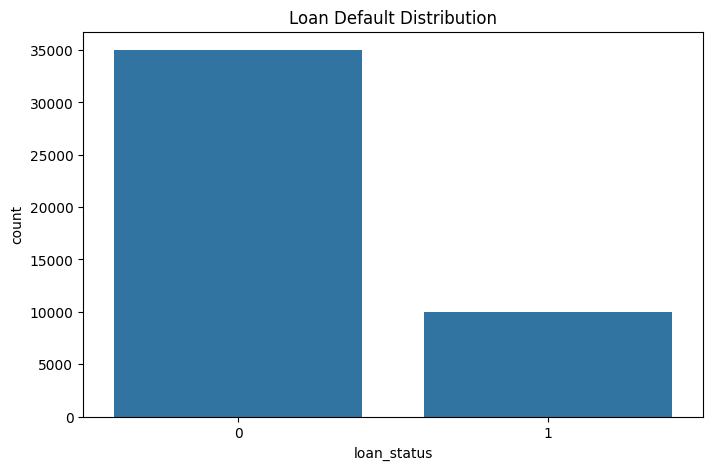

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='loan_status', data=data)
plt.title('Loan Default Distribution')
plt.show()

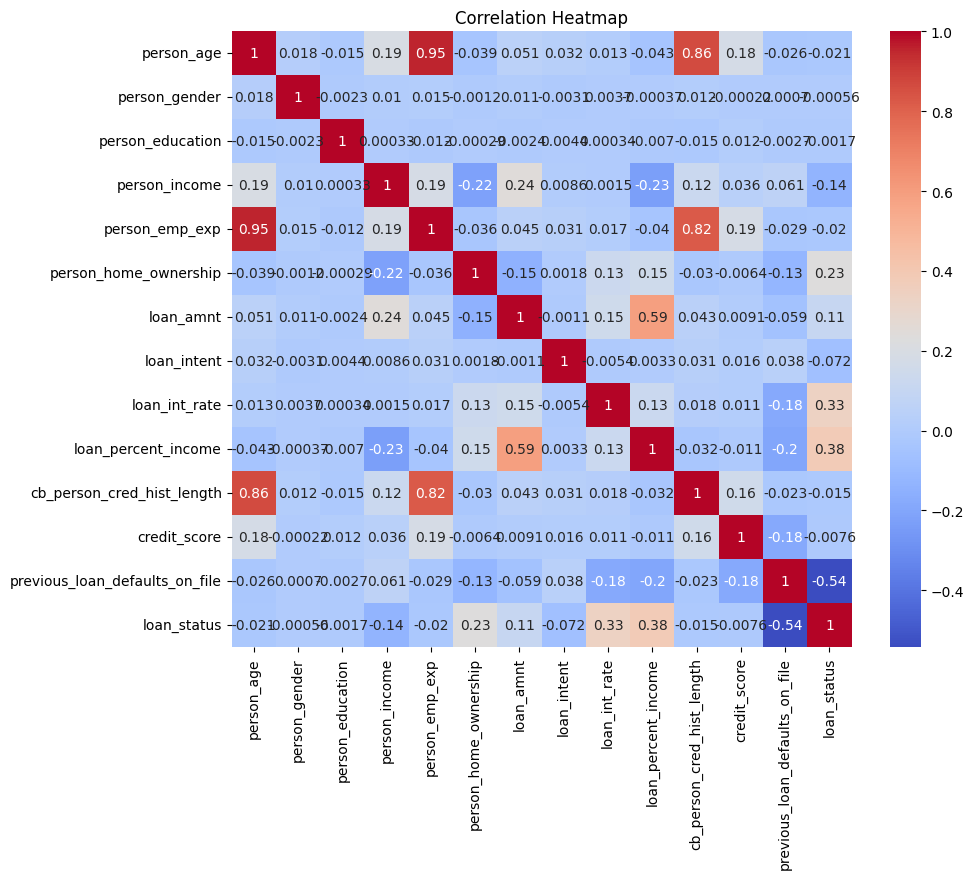

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
gb_model = GradientBoostingClassifier(learning_rate=0.1, n_estimators=300)
rf_model = RandomForestClassifier(n_estimators=500, max_depth=15)

In [ ]:
gb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=500)

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred)
    }

gb_results = evaluate_model(gb_model, X_test, y_test)
rf_results = evaluate_model(rf_model, X_test, y_test)

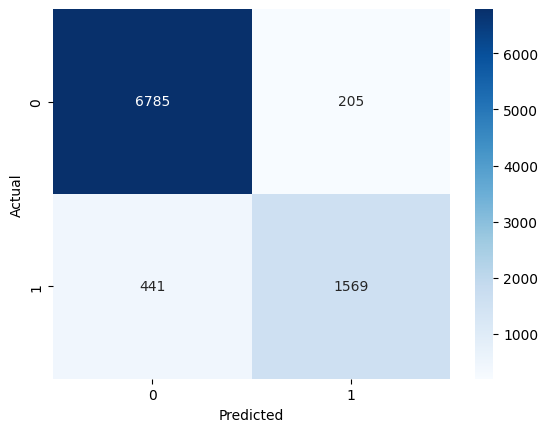

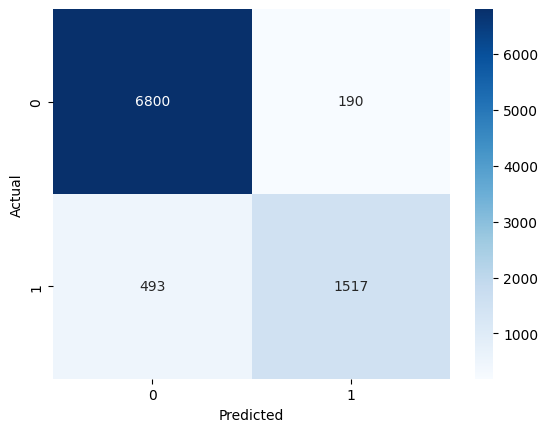

In [ ]:
def plot_confusion_matrix(model, X_test, y_test):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_confusion_matrix(gb_model, X_test, y_test)
plot_confusion_matrix(rf_model, X_test, y_test)

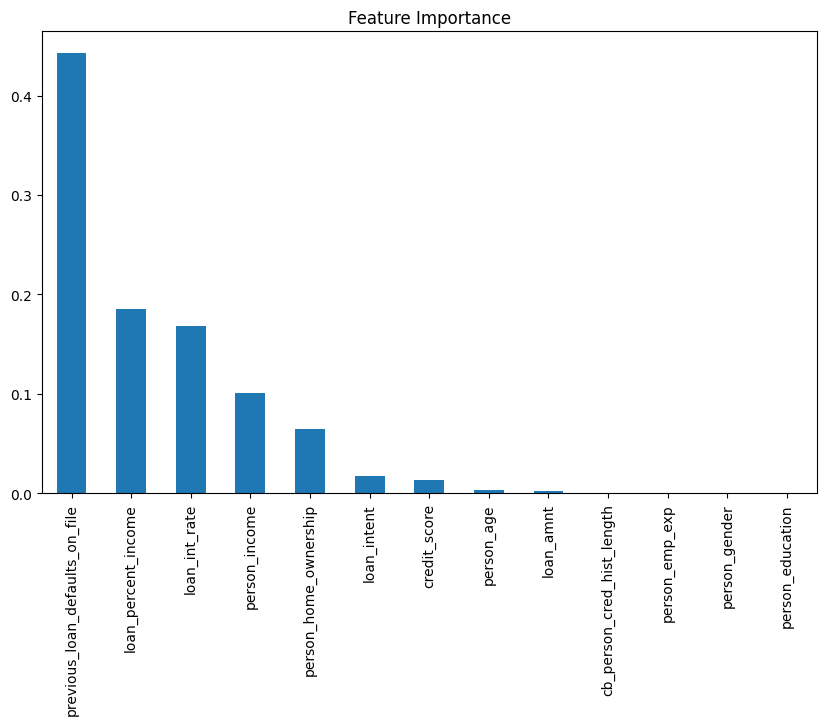

In [ ]:
importances = pd.Series(gb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10, 6))
plt.title('Feature Importance')
plt.show()

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred)
    }

gb_results = evaluate_model(gb_model, X_test, y_test)
rf_results = evaluate_model(rf_model, X_test, y_test)
gb_results, rf_results

({'Accuracy': 0.9282222222222222,
  'Precision': 0.8844419391206313,
  'Recall': 0.7805970149253731,
  'F1-score': 0.8292811839323467,
  'AUC-ROC': np.float64(0.875634702026349)},
 {'Accuracy': 0.9241111111111111,
  'Precision': 0.8886936145284124,
  'Recall': 0.754726368159204,
  'F1-score': 0.8162496637072908,
  'AUC-ROC': np.float64(0.8637723400166549)})

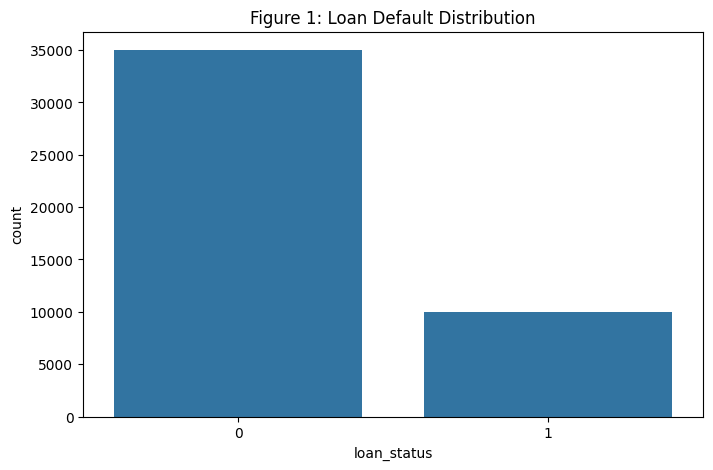

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='loan_status', data=data)
plt.title('Figure 1: Loan Default Distribution')
plt.show()

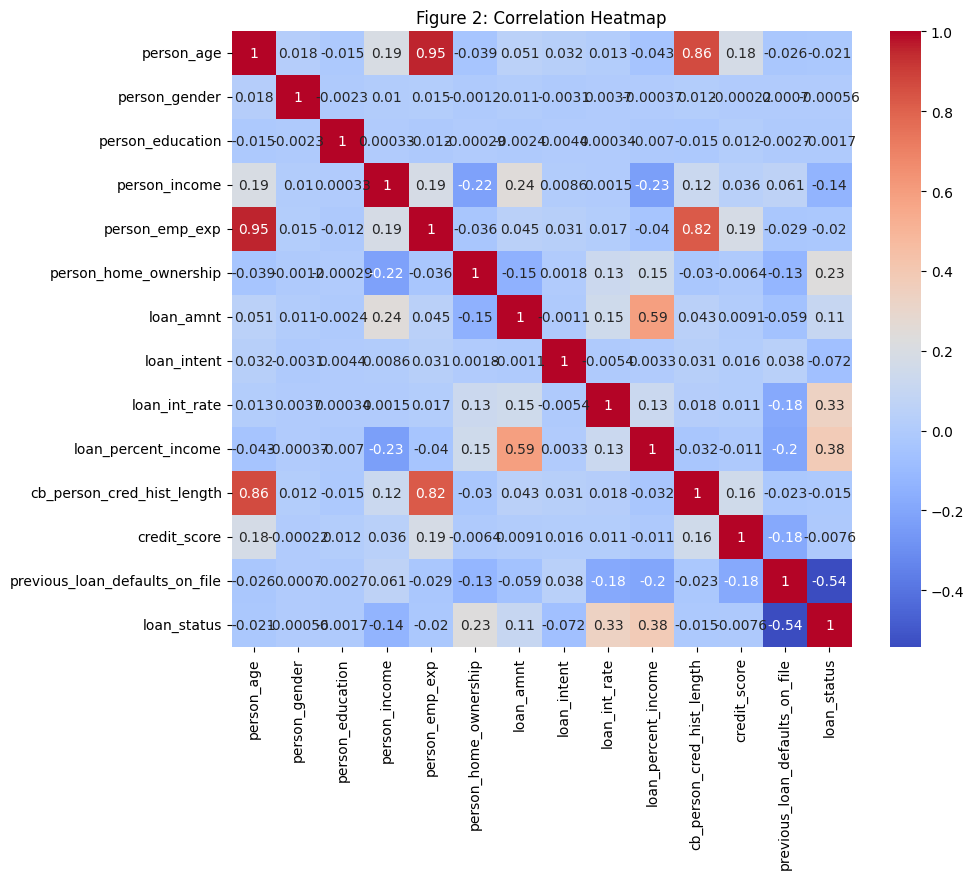

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Figure 2: Correlation Heatmap')
plt.show()

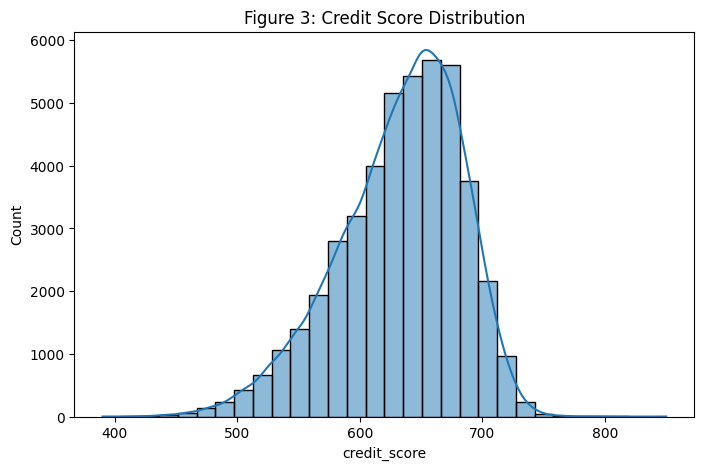

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data['credit_score'], bins=30, kde=True)
plt.title('Figure 3: Credit Score Distribution')
plt.show()

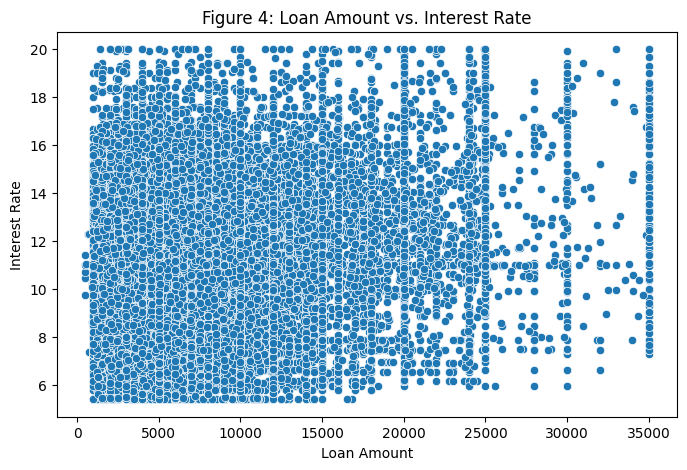

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='loan_amnt', y='loan_int_rate', data=data)
plt.title('Figure 4: Loan Amount vs. Interest Rate')
plt.xlabel('Loan Amount')
plt.ylabel('Interest Rate')
plt.show()

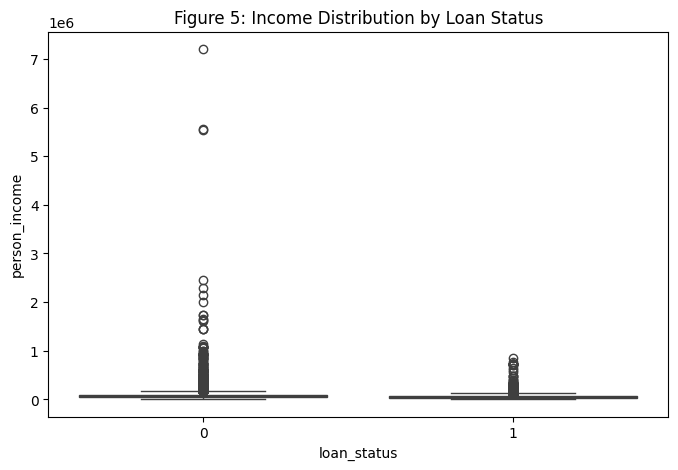

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='person_income', data=data)
plt.title('Figure 5: Income Distribution by Loan Status')
plt.show()

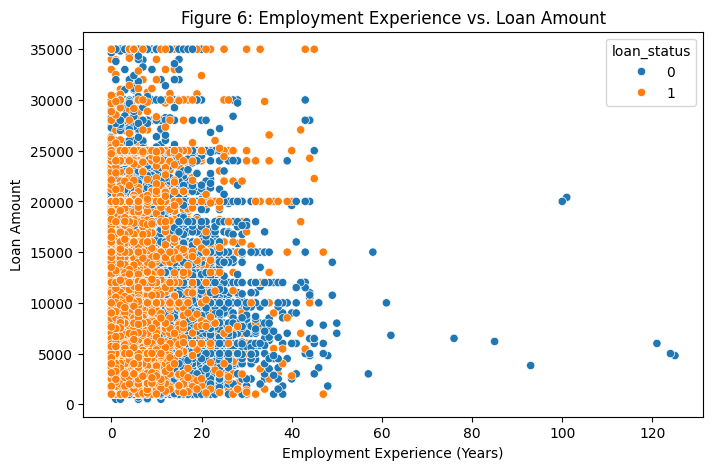

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='person_emp_exp', y='loan_amnt', hue='loan_status', data=data)
plt.title('Figure 6: Employment Experience vs. Loan Amount')
plt.xlabel('Employment Experience (Years)')
plt.ylabel('Loan Amount')
plt.show()

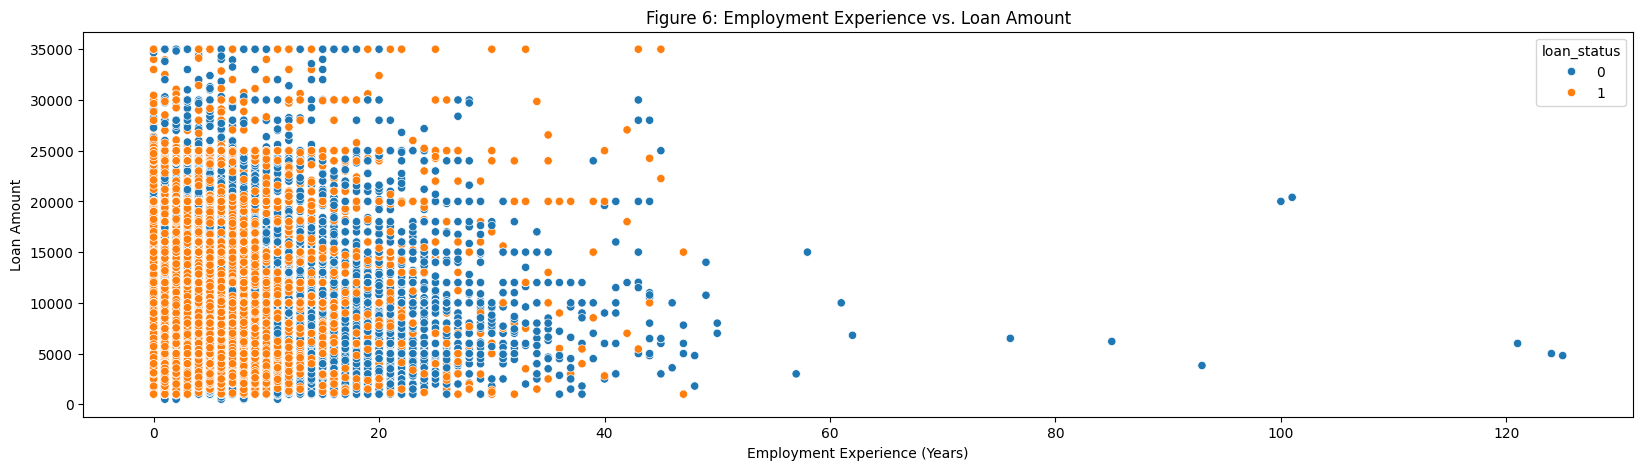

In [ ]:
plt.figure(figsize=(20, 5))
sns.scatterplot(x='person_emp_exp', y='loan_amnt', hue='loan_status', data=data)
plt.title('Figure 6: Employment Experience vs. Loan Amount')
plt.xlabel('Employment Experience (Years)')
plt.ylabel('Loan Amount')
plt.show()

<ipython-input-52-32cae480270d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=data['loan_status'].value_counts().index,


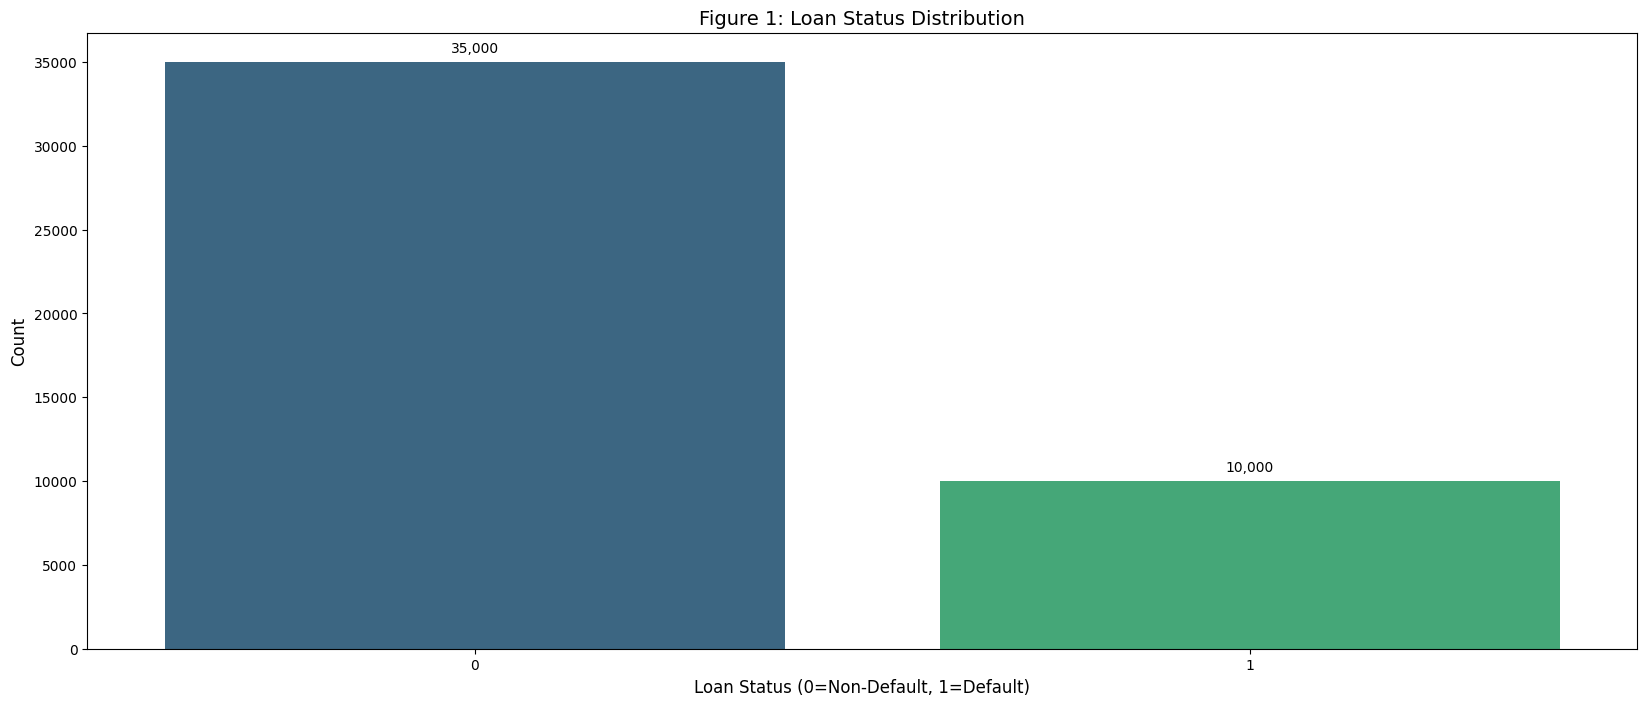

In [ ]:
plt.figure(figsize=(20,8))
ax = sns.barplot(x=data['loan_status'].value_counts().index,
                y=data['loan_status'].value_counts(),
                palette='viridis')
plt.title('Figure 1: Loan Status Distribution', fontsize=14)
plt.xlabel('Loan Status (0=Non-Default, 1=Default)', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points')
plt.show()

<ipython-input-60-2eaf29c1cc16>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_labels, y=edu_counts.values, palette='mako')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'High School'),
  Text(1, 0, 'College'),
  Text(2, 0, 'Bachelor'),
  Text(3, 0, 'Master'),
  Text(4, 0, 'PhD')])

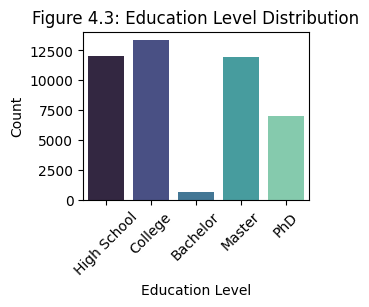

In [ ]:
# Education level
plt.subplot(2,2,3)
edu_counts = data['person_education'].value_counts().sort_index()
edu_labels = ['High School', 'College', 'Bachelor', 'Master', 'PhD']
sns.barplot(x=edu_labels, y=edu_counts.values, palette='mako')
plt.title('Figure 4.3: Education Level Distribution', fontsize=12)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)

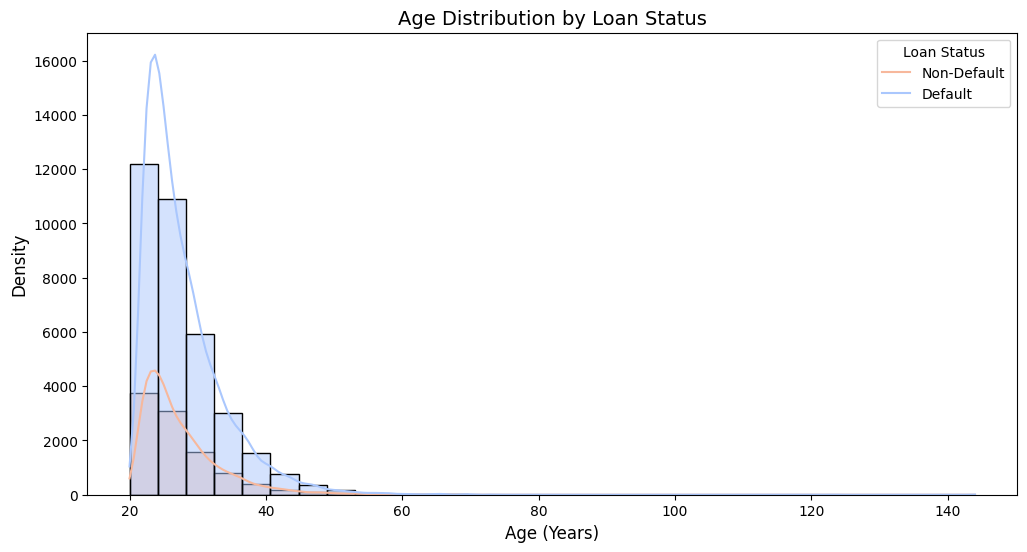

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(data=data, x='person_age', hue='loan_status',
             bins=30, kde=True, palette='coolwarm')
plt.title('Age Distribution by Loan Status', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Loan Status', labels=['Non-Default', 'Default'])
plt.show()

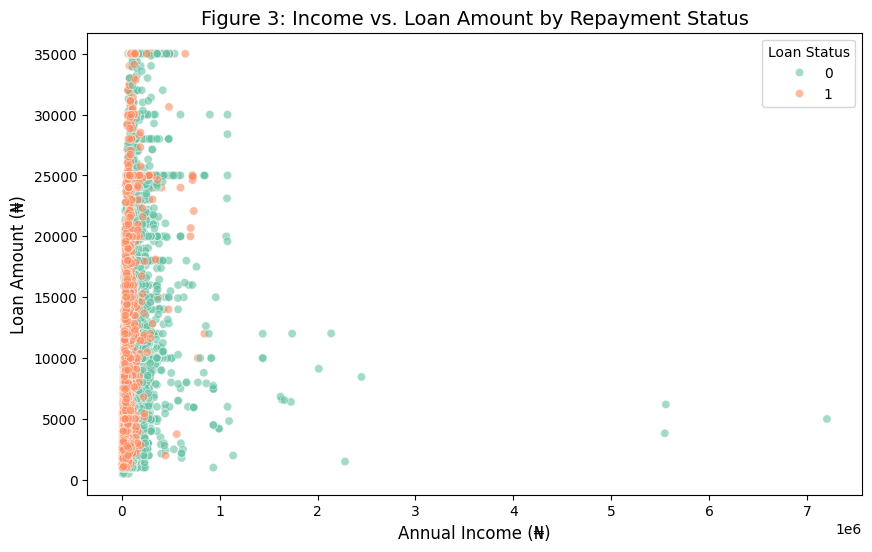

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='person_income', y='loan_amnt',
                hue='loan_status', palette='Set2', alpha=0.6)
plt.title('Figure 3: Income vs. Loan Amount by Repayment Status', fontsize=14)
plt.xlabel('Annual Income (₦)', fontsize=12)
plt.ylabel('Loan Amount (₦)', fontsize=12)
plt.legend(title='Loan Status')
plt.show()

In [ ]:
# Generate demographic summary statistics
demographic_summary = data[['person_age', 'person_income', 'person_emp_exp']].describe()
demographic_summary.loc['skewness'] = [
    data['person_age'].skew(),
    data['person_income'].skew(),
    data['person_emp_exp'].skew()
]
print(demographic_summary.round(2))

          person_age  person_income  person_emp_exp
count       45000.00       45000.00        45000.00
mean           27.76       80319.05            5.41
std             6.05       80422.50            6.06
min            20.00        8000.00            0.00
25%            24.00       47204.00            1.00
50%            26.00       67048.00            4.00
75%            30.00       95789.25            8.00
max           144.00     7200766.00          125.00
skewness        2.55          34.14            2.59


In [ ]:
# Gender-default cross-tabulation
gender_table = pd.crosstab(
    data['person_gender'],
    data['loan_status'],
    margins=True,
    normalize='index'
).round(3)*100
gender_table

loan_status,0,1
person_gender,,
0,77.8,22.2
1,77.8,22.2
All,77.8,22.2


In [ ]:
# Education-default analysis
edu_rates = data.groupby('person_education')['loan_status'].agg(['mean','count'])
edu_rates.columns = ['Default Rate','Count']
print(edu_rates.round(3))

                  Default Rate  Count
person_education                     
0                        0.220  12028
1                        0.225  13399
2                        0.229    621
3                        0.223  11972
4                        0.218   6980


/usr/local/lib/python3.11/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.11/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.11/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.11/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.11/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/usr/local/lib/python3.11/dist-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid

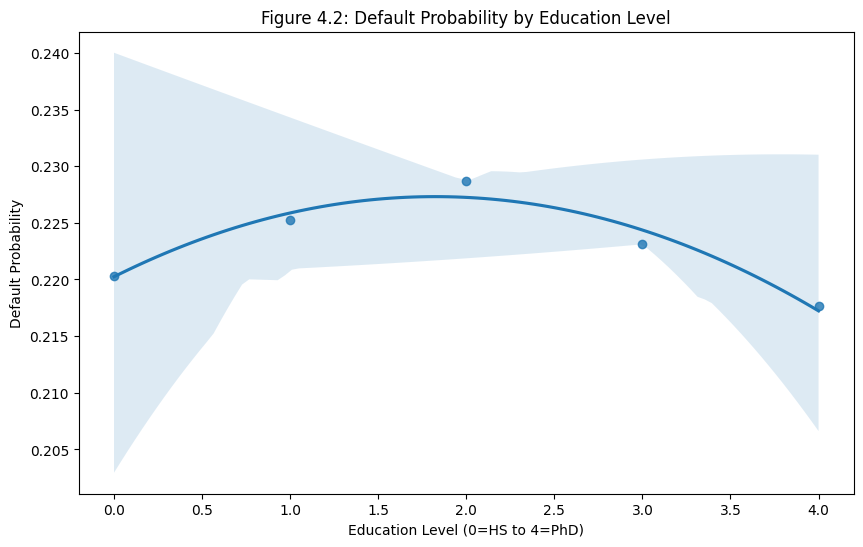

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    x=edu_rates.index,
    y=edu_rates['Default Rate'],
    order=2,
    ci=95
)
plt.title('Figure 4.2: Default Probability by Education Level')
plt.xlabel('Education Level (0=HS to 4=PhD)')
plt.ylabel('Default Probability')
plt.show()

In [ ]:
import statsmodels.api as sm

# Prepare variables
X = data[['credit_score','loan_percent_income','person_gender','person_education','person_age']]
X = sm.add_constant(X)
y = data['loan_status']

# Run model
logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.459436
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                45000
Model:                          Logit   Df Residuals:                    44994
Method:                           MLE   Df Model:                            5
Date:                Tue, 01 Apr 2025   Pseudo R-squ.:                  0.1327
Time:                        15:53:42   Log-Likelihood:                -20675.
converged:                       True   LL-Null:                       -23837.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -2.7175      0.161    -16.876      0.000      -3.033      -2.402
cr

In [ ]:
from sklearn.model_selection import cross_validate

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=300),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200)
}

metrics = []
for name, model in models.items():
    cv_results = cross_validate(
        model, X, y, cv=5,
        scoring=['accuracy','precision','recall','roc_auc']
    )
    metrics.append({
        'Model': name,
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'AUC-ROC': cv_results['test_roc_auc'].mean()
    })

metrics_df = pd.DataFrame(metrics).set_index('Model')
print(metrics_df.round(3))

                     Accuracy  Precision  Recall  AUC-ROC
Model                                                    
Logistic Regression     0.810      0.714   0.243    0.725
Random Forest           0.790      0.543   0.365    0.683
Gradient Boosting       0.823      0.683   0.383    0.726
